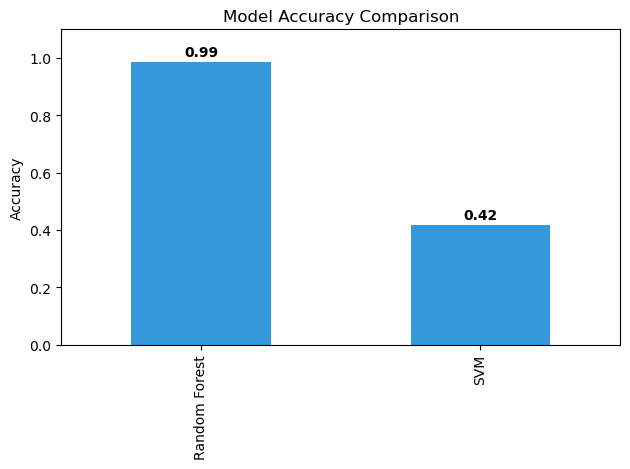

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

# Load data to evaluate models
df = pd.read_csv('../data/processed_dataset.csv')
X = df.drop('Health_Status', axis=1)
y = df['Health_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def eval_model(model_path):
    if not os.path.exists(model_path):
        return {'accuracy': 0.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
    model = joblib.load(model_path)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

rf_path = '../models/random_forest_model.pkl' if os.path.exists('../models/random_forest_model.pkl') else '../../models/random_forest_model.pkl'
svm_path = '../models/svm_model.pkl' if os.path.exists('../models/svm_model.pkl') else '../../models/svm_model.pkl'

rf_metrics = eval_model(rf_path)
svm_metrics = eval_model(svm_path)

results = {
    'Random Forest': rf_metrics,
    'SVM': svm_metrics
}

df_results = pd.DataFrame(results).T
out_dir = '../outputs' if os.path.exists('../outputs') else '../../outputs'
os.makedirs(out_dir, exist_ok=True)
df_results.to_csv(f'{out_dir}/model_comparison.csv')
df_results[['accuracy']].plot(kind='bar', legend=False, color=['#3498db'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
for i, acc in enumerate(df_results['accuracy']):
    plt.text(i, acc + 0.02, f'{acc:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 06 — Model Comparison
Compare Random Forest and SVM model results.